In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import warnings
warnings.simplefilter('ignore')
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import random
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#importing the train dataset
data1=pd.read_csv("Train_Beneficiarydata.csv",encoding='UTF-8')
data2=pd.read_csv("Train_Inpatientdata.csv",encoding='UTF-8')
data3=pd.read_csv("Train_Outpatientdata.csv",encoding='UTF-8')
data4=pd.read_csv("Train.csv",encoding='UTF-8')

data5=pd.read_csv("Test_Beneficiarydata.csv",encoding='UTF-8')
data6=pd.read_csv("Test_Inpatientdata.csv",encoding='UTF-8')
data7=pd.read_csv("Test_Outpatientdata.csv",encoding='UTF-8')
data8=pd.read_csv("Test.csv",encoding='UTF-8')


In [4]:
#duplicates in train

print("duplicates: ",data1.duplicated().sum())
print("duplicates: ",data2.duplicated().sum())
print("duplicates: ",data3.duplicated().sum())
print("duplicates: ",data4.duplicated().sum())

print("duplicates: ",data5.duplicated().sum())
print("duplicates: ",data6.duplicated().sum())
print("duplicates: ",data7.duplicated().sum())
print("duplicates: ",data8.duplicated().sum())




duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0


In [5]:
#shape of train
print("data1: ",data1.shape)
print("data2: ",data2.shape)
print("data3: ",data3.shape)
print("data4: ",data4.shape)

print("data5: ",data5.shape)
print("data6: ",data6.shape)
print("data7: ",data7.shape)
print("data8: ",data8.shape)

data1:  (138556, 25)
data2:  (40474, 30)
data3:  (517737, 27)
data4:  (5410, 2)
data5:  (63968, 25)
data6:  (9551, 30)
data7:  (125841, 27)
data8:  (1353, 1)


In [6]:
data1.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200


In [7]:
data2.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [8]:
data3.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


In [9]:
data4.head()

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [10]:
data5.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11007,1940-09-01,2009-12-01,1,2,0,45,610,12,12,...,2,1,2,1,1,2,0,0,1490,160
2,BENE11010,1936-07-01,NaN,2,1,0,41,30,12,12,...,2,1,1,1,2,2,0,0,1170,660
3,BENE11011,1914-03-01,NaN,2,2,0,1,360,12,12,...,1,1,2,2,1,1,5000,1068,250,320
4,BENE11014,1938-04-01,NaN,2,1,Y,45,780,12,12,...,1,2,1,2,2,2,21260,2136,120,100


In [11]:
data6.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11014,CLM67387,2009-09-09,2009-09-16,PRV57070,9000,PHY317786,PHY427017,NaN,2009-09-09,...,5990,570,41071,4280,4443.0,5849.0,NaN,NaN,NaN,NaN
1,BENE11017,CLM31237,2008-12-25,2009-01-08,PRV54750,14000,PHY314656,PHY426644,NaN,2008-12-25,...,4549,29570,34831,NaN,5551.0,NaN,NaN,NaN,NaN,NaN
2,BENE11026,CLM78930,2009-12-09,2009-12-13,PRV53758,2000,PHY349495,NaN,NaN,2009-12-09,...,78650,7813,4254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11031,CLM56810,2009-06-23,2009-07-06,PRV55825,16000,PHY429538,PHY371893,NaN,2009-06-23,...,4254,41400,5849,41401,8152.0,3320.0,NaN,NaN,NaN,NaN
4,BENE11085,CLM34625,2009-01-20,2009-01-31,PRV52338,19000,PHY397161,NaN,NaN,2009-01-20,...,V6109,7242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
data7.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11001,CLM392397,2009-06-02,2009-06-02,PRV55962,30,PHY347633,NaN,PHY347633,V5832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
1,BENE11001,CLM430760,2009-06-23,2009-06-23,PRV56112,30,PHY381777,NaN,PHY381777,9594,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,BENE11007,CLM233081,2009-03-07,2009-03-07,PRV56979,200,PHY425311,NaN,PHY425311,7248,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11007,CLM496381,2009-07-29,2009-07-29,PRV56573,10,PHY393253,PHY347995,NaN,58889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5939
4,BENE11007,CLM521391,2009-08-12,2009-08-12,PRV56573,10,PHY417685,NaN,PHY382041,V666,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


In [13]:
data8.head()

,Provider
0,PRV51002
1,PRV51006
2,PRV51009
3,PRV51010
4,PRV51018


In [14]:
data1.info()
data2.info()
data3.info()
data4.info()

data5.info()
data6.info()
data7.info()
data8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         138556 non-null  int64 
 12  ChronicCond_Kidn

In [15]:
print(data1.isnull().sum())
print("******************************************")
print(data2.isnull().sum())
print("******************************************")
print(data3.isnull().sum())
print("******************************************")
print(data4.isnull().sum())
print("******************************************")
print("******************************************")
print(data5.isnull().sum())
print("******************************************")
print(data6.isnull().sum())
print("******************************************")
print(data7.isnull().sum())
print("******************************************")
print(data8.isnull().sum())

BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursementAmt                0
IPAnnualDeductibleAmt                   0
OPAnnualReimbursementAmt          

In [16]:
data1['DOB'] = pd.to_datetime(data1['DOB'] , format = '%Y-%m-%d')
data1['DOD'] = pd.to_datetime(data1['DOD'],format = '%Y-%m-%d',errors='ignore')
data1['Age'] = round(((data1['DOD'] - data1['DOB']).dt.days)/365)

data5['DOB'] = pd.to_datetime(data5['DOB'] , format = '%Y-%m-%d')
data5['DOD'] = pd.to_datetime(data5['DOD'],format = '%Y-%m-%d',errors='ignore')
data5['Age'] = round(((data5['DOD'] - data5['DOB']).dt.days)/365)

data1.Age.fillna(round(((pd.to_datetime('2009-12-01' , format = '%Y-%m-%d') - data1['DOB']).dt.days)/365),inplace=True)
data5.Age.fillna(round(((pd.to_datetime('2009-12-01' , format = '%Y-%m-%d') - data5['DOB']).dt.days)/365),inplace=True)


In [17]:
data2['AdmissionDt'] = pd.to_datetime(data2['AdmissionDt'] , format = '%Y-%m-%d')
data2['DischargeDt'] = pd.to_datetime(data2['DischargeDt'],format = '%Y-%m-%d')
data2['AdmitForDays'] = ((data2['DischargeDt'] - data2['AdmissionDt']).dt.days)+1

data2['ClaimStartDt'] = pd.to_datetime(data2['ClaimStartDt'] , format = '%Y-%m-%d')
data2['ClaimEndDt'] = pd.to_datetime(data2['ClaimEndDt'],format = '%Y-%m-%d')
data2['ClaimDays'] = ((data2['ClaimEndDt'] - data2['ClaimStartDt']).dt.days)+1

data3['ClaimStartDt'] = pd.to_datetime(data3['ClaimStartDt'] , format = '%Y-%m-%d')
data3['ClaimEndDt'] = pd.to_datetime(data3['ClaimEndDt'],format = '%Y-%m-%d')
data3['ClaimDays'] = ((data3['ClaimEndDt'] - data3['ClaimStartDt']).dt.days)+1

#test data
data6['AdmissionDt'] = pd.to_datetime(data6['AdmissionDt'] , format = '%Y-%m-%d')
data6['DischargeDt'] = pd.to_datetime(data6['DischargeDt'],format = '%Y-%m-%d')
data6['AdmitForDays'] = ((data6['DischargeDt'] - data6['AdmissionDt']).dt.days)+1

data6['ClaimStartDt'] = pd.to_datetime(data6['ClaimStartDt'] , format = '%Y-%m-%d')
data6['ClaimEndDt'] = pd.to_datetime(data6['ClaimEndDt'],format = '%Y-%m-%d')
data6['ClaimDays'] = ((data6['ClaimEndDt'] - data6['ClaimStartDt']).dt.days)+1

data7['ClaimStartDt'] = pd.to_datetime(data7['ClaimStartDt'] , format = '%Y-%m-%d')
data7['ClaimEndDt'] = pd.to_datetime(data7['ClaimEndDt'],format = '%Y-%m-%d')
data7['ClaimDays'] = ((data7['ClaimEndDt'] - data7['ClaimStartDt']).dt.days)+1


In [18]:
data1.drop('DOD', axis=1, inplace=True)
data1.drop('DOB', axis=1, inplace=True)

data2.drop('DischargeDt', axis=1, inplace=True)
data2.drop('AdmissionDt', axis=1, inplace=True)

data2.drop('ClaimStartDt', axis=1, inplace=True)
data2.drop('ClaimEndDt', axis=1, inplace=True)

data3.drop('ClaimStartDt', axis=1, inplace=True)
data3.drop('ClaimEndDt', axis=1, inplace=True)

#test data
data5.drop('DOD', axis=1, inplace=True)
data5.drop('DOB', axis=1, inplace=True)

data6.drop('DischargeDt', axis=1, inplace=True)
data6.drop('AdmissionDt', axis=1, inplace=True)

data6.drop('ClaimStartDt', axis=1, inplace=True)
data6.drop('ClaimEndDt', axis=1, inplace=True)

data7.drop('ClaimStartDt', axis=1, inplace=True)
data7.drop('ClaimEndDt', axis=1, inplace=True)


In [19]:
data1.head()

,BeneID,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,...,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1,1,0,39,230,12,12,1,2,...,1,1,2,1,1,36000,3204,60,70,67.0
1,BENE11002,2,1,0,39,280,12,12,2,2,...,2,2,2,2,2,0,0,30,50,73.0
2,BENE11003,1,1,0,52,590,12,12,1,2,...,2,1,2,2,2,0,0,90,40,73.0
3,BENE11004,1,1,0,39,270,12,12,1,1,...,1,1,1,1,2,0,0,1810,760,87.0
4,BENE11005,1,1,0,24,680,12,12,2,2,...,1,2,2,2,2,0,0,1790,1200,74.0


In [20]:
data2.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,AdmitForDays,ClaimDays
0,BENE11001,CLM46614,PRV55912,26000,PHY390922,NaN,NaN,7866,1068.0,201,...,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,7
1,BENE11001,CLM66048,PRV55907,5000,PHY318495,PHY318495,NaN,6186,1068.0,750,...,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,3,3
2,BENE11001,CLM68358,PRV56046,5000,PHY372395,NaN,PHY324689,29590,1068.0,883,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4
3,BENE11011,CLM38412,PRV52405,5000,PHY369659,PHY392961,PHY349768,431,1068.0,067,...,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,9,9
4,BENE11014,CLM63689,PRV56614,10000,PHY379376,PHY398258,NaN,78321,1068.0,975,...,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,18,18


In [21]:
data3.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,...,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode,ClaimDays
0,BENE11002,CLM624349,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409,1
1,BENE11003,CLM189947,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380,1
2,BENE11003,CLM438021,PRV57595,10,PHY328821,NaN,NaN,2723,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,1
3,BENE11004,CLM121801,PRV56011,40,PHY334319,NaN,NaN,71988,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,1
4,BENE11004,CLM150998,PRV56011,200,PHY403831,NaN,NaN,82382,30000,72887,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947,1


In [22]:
data5.head()

,BeneID,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,...,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1,1,0,39,230,12,12,1,2,...,1,1,2,1,1,36000,3204,60,70,67.0
1,BENE11007,1,2,0,45,610,12,12,1,1,...,1,2,1,1,2,0,0,1490,160,69.0
2,BENE11010,2,1,0,41,30,12,12,2,1,...,1,1,1,2,2,0,0,1170,660,73.0
3,BENE11011,2,2,0,1,360,12,12,2,1,...,1,2,2,1,1,5000,1068,250,320,96.0
4,BENE11014,2,1,Y,45,780,12,12,2,1,...,2,1,2,2,2,21260,2136,120,100,72.0


In [23]:
data6.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,AdmitForDays,ClaimDays
0,BENE11014,CLM67387,PRV57070,9000,PHY317786,PHY427017,NaN,5789,1068.0,332,...,41071,4280,4443.0,5849.0,NaN,NaN,NaN,NaN,8,8
1,BENE11017,CLM31237,PRV54750,14000,PHY314656,PHY426644,NaN,5939,1068.0,661,...,34831,NaN,5551.0,NaN,NaN,NaN,NaN,NaN,15,15
2,BENE11026,CLM78930,PRV53758,2000,PHY349495,NaN,NaN,4019,1068.0,241,...,4254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,5
3,BENE11031,CLM56810,PRV55825,16000,PHY429538,PHY371893,NaN,8208,1068.0,564,...,5849,41401,8152.0,3320.0,NaN,NaN,NaN,NaN,14,14
4,BENE11085,CLM34625,PRV52338,19000,PHY397161,NaN,NaN,4279,1068.0,880,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,12


In [24]:
data7.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,...,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode,ClaimDays
0,BENE11001,CLM392397,PRV55962,30,PHY347633,NaN,PHY347633,V5832,V5861,2724,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,1
1,BENE11001,CLM430760,PRV56112,30,PHY381777,NaN,PHY381777,9594,E9174,4019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,1
2,BENE11007,CLM233081,PRV56979,200,PHY425311,NaN,PHY425311,7248,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,1
3,BENE11007,CLM496381,PRV56573,10,PHY393253,PHY347995,NaN,58889,2449,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5939,1
4,BENE11007,CLM521391,PRV56573,10,PHY417685,NaN,PHY382041,V666,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,1


In [25]:
print("**************TRAIN DATA 1 ****************")
print((data1.isna().sum()/len(data1))*100)
print("**************TEST DATA 5 ****************")
print((data5.isna().sum()/len(data1))*100)

**************TRAIN DATA 1 ****************
BeneID                             0.0
Gender                             0.0
Race                               0.0
RenalDiseaseIndicator              0.0
State                              0.0
County                             0.0
NoOfMonths_PartACov                0.0
NoOfMonths_PartBCov                0.0
ChronicCond_Alzheimer              0.0
ChronicCond_Heartfailure           0.0
ChronicCond_KidneyDisease          0.0
ChronicCond_Cancer                 0.0
ChronicCond_ObstrPulmonary         0.0
ChronicCond_Depression             0.0
ChronicCond_Diabetes               0.0
ChronicCond_IschemicHeart          0.0
ChronicCond_Osteoporasis           0.0
ChronicCond_rheumatoidarthritis    0.0
ChronicCond_stroke                 0.0
IPAnnualReimbursementAmt           0.0
IPAnnualDeductibleAmt              0.0
OPAnnualReimbursementAmt           0.0
OPAnnualDeductibleAmt              0.0
Age                                0.0
dtype: float64
*****

In [26]:
print("**************TRAIN DATA 2 ****************")

print((data2.isna().sum()/len(data2))*100)

print("**************TEST DATA 6 ****************")

print((data6.isna().sum()/len(data6))*100)

**************TRAIN DATA 2 ****************
BeneID                      0.000000
ClaimID                     0.000000
Provider                    0.000000
InscClaimAmtReimbursed      0.000000
AttendingPhysician          0.276721
OperatingPhysician         41.122696
OtherPhysician             88.412314
ClmAdmitDiagnosisCode       0.000000
DeductibleAmtPaid           2.221179
DiagnosisGroupCode          0.000000
ClmDiagnosisCode_1          0.000000
ClmDiagnosisCode_2          0.558383
ClmDiagnosisCode_3          1.670208
ClmDiagnosisCode_4          3.790087
ClmDiagnosisCode_5          7.150269
ClmDiagnosisCode_6         11.953353
ClmDiagnosisCode_7         17.932500
ClmDiagnosisCode_8         24.563918
ClmDiagnosisCode_9         33.347334
ClmDiagnosisCode_10        90.297475
ClmProcedureCode_1         42.807728
ClmProcedureCode_2         86.524683
ClmProcedureCode_3         97.615753
ClmProcedureCode_4         99.713396
ClmProcedureCode_5         99.977764
ClmProcedureCode_6        100.0

In [27]:
x1=(data2.isna().sum()/len(data2))*100
col_Todrop_data2 = x1[x1> 50].index.tolist()

In [28]:
print("**************TRAIN DATA 3 ****************")
print((data3.isna().sum()/len(data3))*100)
print("**************TEST DATA 7 ****************")
print((data7.isna().sum()/len(data7))*100)


**************TRAIN DATA 3 ****************
BeneID                      0.000000
ClaimID                     0.000000
Provider                    0.000000
InscClaimAmtReimbursed      0.000000
AttendingPhysician          0.269635
OperatingPhysician         82.497484
OtherPhysician             62.327205
ClmDiagnosisCode_1          2.018979
ClmDiagnosisCode_2         37.737307
ClmDiagnosisCode_3         60.741264
ClmDiagnosisCode_4         75.741351
ClmDiagnosisCode_5         85.640586
ClmDiagnosisCode_6         90.582864
ClmDiagnosisCode_7         93.633640
ClmDiagnosisCode_8         95.574587
ClmDiagnosisCode_9         97.134066
ClmDiagnosisCode_10        99.790820
ClmProcedureCode_1         99.968710
ClmProcedureCode_2         99.993047
ClmProcedureCode_3         99.999227
ClmProcedureCode_4         99.999614
ClmProcedureCode_5        100.000000
ClmProcedureCode_6        100.000000
DeductibleAmtPaid           0.000000
ClmAdmitDiagnosisCode      79.637345
ClaimDays                   0.0

In [29]:
x2=(data3.isna().sum()/len(data2))*100
col_Todrop_data3 = x2[x2> 50].index.tolist()

In [30]:
for i in col_Todrop_data2:
    data2.drop(i, axis=1, inplace=True)
    data6.drop(i, axis=1, inplace=True)
for i in col_Todrop_data3:
    data3.drop(i, axis=1, inplace=True)
    data7.drop(i, axis=1, inplace=True)

In [31]:
#train inpatient data
merged_data2 = pd.merge(data2, data1, on='BeneID', how='left')
fdata1=pd.DataFrame(merged_data2)

#test inpatient data
merged_data2 = pd.merge(data6, data5, on='BeneID', how='left')
fdata1_test=pd.DataFrame(merged_data2)

#train outpatient data
merged_data2 = pd.merge(data3, data1, on='BeneID', how='left')
fdata2=pd.DataFrame(merged_data2)

#test outpatient data
merged_data2 = pd.merge(data7, data5, on='BeneID', how='left')
fdata2_test=pd.DataFrame(merged_data2)


In [32]:
fdata1.shape


(40474, 44)

In [33]:
fdata1_test.shape

(9551, 44)

In [34]:
fdata2.shape

(517737, 31)

In [35]:
fdata2_test.shape

(125841, 31)

In [36]:
#merging the target data inpatient
merged_data2 = pd.merge(fdata1, data4, on='Provider', how='left')
fdata1=pd.DataFrame(merged_data2)

merged_data2 = pd.merge(fdata1_test, data8, on='Provider', how='left')
fdata1_test=pd.DataFrame(merged_data2)

#merging the target data in out patient
merged_data2 = pd.merge(fdata2, data4, on='Provider', how='left')
fdata2=pd.DataFrame(merged_data2)

merged_data2 = pd.merge(fdata2_test, data8, on='Provider', how='left')
fdata2_test=pd.DataFrame(merged_data2)

In [37]:
fdata1.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,ClmDiagnosisCode_1,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,BENE11001,CLM46614,PRV55912,26000,PHY390922,NaN,7866,1068.0,201,1970,...,1,2,1,1,36000,3204,60,70,67.0,Yes
1,BENE11001,CLM66048,PRV55907,5000,PHY318495,PHY318495,6186,1068.0,750,6186,...,1,2,1,1,36000,3204,60,70,67.0,No
2,BENE11001,CLM68358,PRV56046,5000,PHY372395,NaN,29590,1068.0,883,29623,...,1,2,1,1,36000,3204,60,70,67.0,No
3,BENE11011,CLM38412,PRV52405,5000,PHY369659,PHY392961,431,1068.0,067,43491,...,2,2,1,1,5000,1068,250,320,96.0,No
4,BENE11014,CLM63689,PRV56614,10000,PHY379376,PHY398258,78321,1068.0,975,042,...,1,2,2,2,21260,2136,120,100,72.0,No


In [38]:
fdata1.tail()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,ClmDiagnosisCode_1,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
40469,BENE159167,CLM69886,PRV53671,7000,PHY345332,PHY319565,2859,1068.0,812,2851,...,1,2,1,2,11400,2136,520,280,53.0,Yes
40470,BENE159175,CLM74504,PRV54981,4000,PHY342806,PHY365497,79902,1068.0,228,42823,...,1,2,2,2,4000,1068,0,0,56.0,No
40471,BENE159177,CLM76485,PRV56588,3000,PHY423220,PHY332752,78605,1068.0,302,4280,...,1,1,1,2,8000,2136,1920,400,90.0,Yes
40472,BENE159177,CLM79949,PRV56575,5000,PHY353156,NaN,7802,1068.0,309,7802,...,1,1,1,2,8000,2136,1920,400,90.0,Yes
40473,BENE159188,CLM69948,PRV54765,15000,PHY431177,PHY352941,1536,1068.0,340,1540,...,1,2,2,2,15800,1068,6140,60,71.0,Yes


In [39]:
fdata1_test.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,ClmDiagnosisCode_1,...,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11014,CLM67387,PRV57070,9000,PHY317786,PHY427017,5789,1068.0,332,5780,...,2,1,2,2,2,21260,2136,120,100,72.0
1,BENE11017,CLM31237,PRV54750,14000,PHY314656,PHY426644,5939,1068.0,661,1889,...,1,1,2,1,1,22000,2136,1400,840,70.0
2,BENE11026,CLM78930,PRV53758,2000,PHY349495,NaN,4019,1068.0,241,4010,...,2,1,2,2,2,2000,1068,0,0,72.0
3,BENE11031,CLM56810,PRV55825,16000,PHY429538,PHY371893,8208,1068.0,564,8208,...,2,1,1,2,2,23650,2136,40,0,65.0
4,BENE11085,CLM34625,PRV52338,19000,PHY397161,NaN,4279,1068.0,880,29654,...,1,1,1,2,2,19000,1068,1670,520,47.0


In [40]:
fdata1['PotentialFraud'].isnull().sum()

np.int64(0)

In [41]:
fdata1.duplicated().sum()

np.int64(0)

In [42]:
fdata2['PotentialFraud'].isnull().sum()

np.int64(0)

In [43]:
fdata1.duplicated().sum()

np.int64(0)

In [44]:
fdata2.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,ClmDiagnosisCode_1,DeductibleAmtPaid,ClaimDays,Gender,Race,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,BENE11002,CLM624349,PRV56011,30,PHY326117,78943,0,1,2,1,...,2,2,2,2,0,0,30,50,73.0,Yes
1,BENE11003,CLM189947,PRV57610,80,PHY362868,6115,0,1,1,1,...,1,2,2,2,0,0,90,40,73.0,No
2,BENE11003,CLM438021,PRV57595,10,PHY328821,2723,0,1,1,1,...,1,2,2,2,0,0,90,40,73.0,No
3,BENE11004,CLM121801,PRV56011,40,PHY334319,71988,0,1,1,1,...,1,1,1,2,0,0,1810,760,87.0,Yes
4,BENE11004,CLM150998,PRV56011,200,PHY403831,82382,0,1,1,1,...,1,1,1,2,0,0,1810,760,87.0,Yes


In [45]:
fdata2_test.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,ClmDiagnosisCode_1,DeductibleAmtPaid,ClaimDays,Gender,Race,...,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,CLM392397,PRV55962,30,PHY347633,V5832,0,1,1,1,...,1,1,2,1,1,36000,3204,60,70,67.0
1,BENE11001,CLM430760,PRV56112,30,PHY381777,9594,0,1,1,1,...,1,1,2,1,1,36000,3204,60,70,67.0
2,BENE11007,CLM233081,PRV56979,200,PHY425311,7248,0,1,1,2,...,1,2,1,1,2,0,0,1490,160,69.0
3,BENE11007,CLM496381,PRV56573,10,PHY393253,58889,0,1,1,2,...,1,2,1,1,2,0,0,1490,160,69.0
4,BENE11007,CLM521391,PRV56573,10,PHY417685,V666,0,1,1,2,...,1,2,1,1,2,0,0,1490,160,69.0


In [46]:
fdata1_test.isna().sum()

BeneID                                0
ClaimID                               0
Provider                              0
InscClaimAmtReimbursed                0
AttendingPhysician                   31
OperatingPhysician                 3962
ClmAdmitDiagnosisCode                 0
DeductibleAmtPaid                   196
DiagnosisGroupCode                    0
ClmDiagnosisCode_1                    0
ClmDiagnosisCode_2                   54
ClmDiagnosisCode_3                  169
ClmDiagnosisCode_4                  404
ClmDiagnosisCode_5                  719
ClmDiagnosisCode_6                 1197
ClmDiagnosisCode_7                 1736
ClmDiagnosisCode_8                 2360
ClmDiagnosisCode_9                 3238
ClmProcedureCode_1                 4118
AdmitForDays                          0
ClaimDays                             0
Gender                                0
Race                                  0
RenalDiseaseIndicator                 0
State                                 0


In [47]:
fdata2_test.isna().sum()

BeneID                                0
ClaimID                               0
Provider                              0
InscClaimAmtReimbursed                0
AttendingPhysician                  316
ClmDiagnosisCode_1                 2578
DeductibleAmtPaid                     0
ClaimDays                             0
Gender                                0
Race                                  0
RenalDiseaseIndicator                 0
State                                 0
County                                0
NoOfMonths_PartACov                   0
NoOfMonths_PartBCov                   0
ChronicCond_Alzheimer                 0
ChronicCond_Heartfailure              0
ChronicCond_KidneyDisease             0
ChronicCond_Cancer                    0
ChronicCond_ObstrPulmonary            0
ChronicCond_Depression                0
ChronicCond_Diabetes                  0
ChronicCond_IschemicHeart             0
ChronicCond_Osteoporasis              0
ChronicCond_rheumatoidarthritis       0


In [48]:
print(fdata1.shape)
print("--------------------------------------------------")
fdata1.isna().sum()

(40474, 45)
--------------------------------------------------


BeneID                                 0
ClaimID                                0
Provider                               0
InscClaimAmtReimbursed                 0
AttendingPhysician                   112
OperatingPhysician                 16644
ClmAdmitDiagnosisCode                  0
DeductibleAmtPaid                    899
DiagnosisGroupCode                     0
ClmDiagnosisCode_1                     0
ClmDiagnosisCode_2                   226
ClmDiagnosisCode_3                   676
ClmDiagnosisCode_4                  1534
ClmDiagnosisCode_5                  2894
ClmDiagnosisCode_6                  4838
ClmDiagnosisCode_7                  7258
ClmDiagnosisCode_8                  9942
ClmDiagnosisCode_9                 13497
ClmProcedureCode_1                 17326
AdmitForDays                           0
ClaimDays                              0
Gender                                 0
Race                                   0
RenalDiseaseIndicator                  0
State           

In [49]:
arrC=['AttendingPhysician','OperatingPhysician','ClmDiagnosisCode_2','ClmDiagnosisCode_3','ClmDiagnosisCode_4'
                           ,'ClmDiagnosisCode_5','ClmDiagnosisCode_6','ClmDiagnosisCode_7','ClmDiagnosisCode_8','ClmDiagnosisCode_9']
arrN=['DeductibleAmtPaid','ClmProcedureCode_1']  #arrc: all catergorical values arrN: all numerical values

#imputation inpatient
knn_imputer = KNNImputer(n_neighbors=5)

chunk_size = 1000  #will impute 1000 at a time since dataset is large it takes time

for i in range(0, len(fdata1), chunk_size):
    chunk_data = fdata1.iloc[i:i + chunk_size]
    imputed_chunk = knn_imputer.fit_transform(chunk_data[arrN])

    fdata1.loc[i:i + chunk_size - 1, arrN] = imputed_chunk

for i in arrC:
    categories = fdata1[i].dropna().unique()
    fdata1[i].fillna(random.choice(categories), inplace=True)

In [50]:
print(fdata2.shape)
print('--------------------------')
fdata2.isna().sum()

(517737, 32)
--------------------------


BeneID                                 0
ClaimID                                0
Provider                               0
InscClaimAmtReimbursed                 0
AttendingPhysician                  1396
ClmDiagnosisCode_1                 10453
DeductibleAmtPaid                      0
ClaimDays                              0
Gender                                 0
Race                                   0
RenalDiseaseIndicator                  0
State                                  0
County                                 0
NoOfMonths_PartACov                    0
NoOfMonths_PartBCov                    0
ChronicCond_Alzheimer                  0
ChronicCond_Heartfailure               0
ChronicCond_KidneyDisease              0
ChronicCond_Cancer                     0
ChronicCond_ObstrPulmonary             0
ChronicCond_Depression                 0
ChronicCond_Diabetes                   0
ChronicCond_IschemicHeart              0
ChronicCond_Osteoporasis               0
ChronicCond_rheu

In [51]:
#imputation outpatient
arrC=['AttendingPhysician','ClmDiagnosisCode_1']
for i in arrC:
    categories = fdata2[i].dropna().unique()
    fdata2[i].fillna(random.choice(categories), inplace=True)

In [52]:
fdata2.isna().sum()

BeneID                             0
ClaimID                            0
Provider                           0
InscClaimAmtReimbursed             0
AttendingPhysician                 0
ClmDiagnosisCode_1                 0
DeductibleAmtPaid                  0
ClaimDays                          0
Gender                             0
Race                               0
RenalDiseaseIndicator              0
State                              0
County                             0
NoOfMonths_PartACov                0
NoOfMonths_PartBCov                0
ChronicCond_Alzheimer              0
ChronicCond_Heartfailure           0
ChronicCond_KidneyDisease          0
ChronicCond_Cancer                 0
ChronicCond_ObstrPulmonary         0
ChronicCond_Depression             0
ChronicCond_Diabetes               0
ChronicCond_IschemicHeart          0
ChronicCond_Osteoporasis           0
ChronicCond_rheumatoidarthritis    0
ChronicCond_stroke                 0
IPAnnualReimbursementAmt           0
I

In [53]:
fdata1.duplicated().sum()

np.int64(0)

In [54]:
fdata2.duplicated().sum()

np.int64(0)

In [55]:
fdata1.columns

Index(['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'OperatingPhysician', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1',
       'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4',
       'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7',
       'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmProcedureCode_1',
       'AdmitForDays', 'ClaimDays', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
       'IPAnnualDeductibleAmt', 'OPAnnualReimbur

In [56]:
fdata1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 45 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BeneID                           40474 non-null  object 
 1   ClaimID                          40474 non-null  object 
 2   Provider                         40474 non-null  object 
 3   InscClaimAmtReimbursed           40474 non-null  int64  
 4   AttendingPhysician               40474 non-null  object 
 5   OperatingPhysician               40474 non-null  object 
 6   ClmAdmitDiagnosisCode            40474 non-null  object 
 7   DeductibleAmtPaid                40474 non-null  float64
 8   DiagnosisGroupCode               40474 non-null  object 
 9   ClmDiagnosisCode_1               40474 non-null  object 
 10  ClmDiagnosisCode_2               40474 non-null  object 
 11  ClmDiagnosisCode_3               40474 non-null  object 
 12  ClmDiagnosisCode_4

In [57]:
#label encoding for Inpatient data
arr1=fdata1.select_dtypes(include=['object']).columns.tolist()
arr1.remove('PotentialFraud')
for i in arr1:
    sampler1=LabelEncoder()
    sampler2=LabelEncoder()
    fdata1[i]=sampler1.fit_transform(fdata1[i])
    fdata1_test[i]=sampler2.fit_transform(fdata1_test[i])

fdata1['PotentialFraud']=fdata1['PotentialFraud'].map({'Yes':1,'No':0})

#label encoding for outpatient data
arr2=fdata2.select_dtypes(include=['object']).columns.tolist()
arr2.remove('PotentialFraud')
for i in arr2:
    sampler3=LabelEncoder()
    sampler4=LabelEncoder()
    fdata2[i]=sampler3.fit_transform(fdata2[i])
    fdata2_test[i]=sampler4.fit_transform(fdata2_test[i])

fdata2['PotentialFraud'] = fdata2['PotentialFraud'].map({'Yes':1,'No':0})

In [58]:
fdata1.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,ClmDiagnosisCode_1,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,2141,12665,1543,26000,7483,6821,1464,1068.0,154,221,...,1,2,1,1,36000,3204,60,70,67.0,1
1,2141,28399,1540,5000,657,484,1127,1068.0,580,1396,...,1,2,1,1,36000,3204,60,70,67.0,0
2,2141,30241,1585,5000,5789,6821,400,1068.0,665,531,...,1,2,1,1,36000,3204,60,70,67.0,0
3,2163,6040,540,5000,5542,5530,679,1068.0,52,886,...,2,2,1,1,5000,1068,250,320,96.0,0
4,2173,26500,1753,10000,6412,5896,1432,1068.0,721,41,...,1,2,2,2,21260,2136,120,100,72.0,0


In [59]:
fdata1.shape

(40474, 45)

<Axes: >

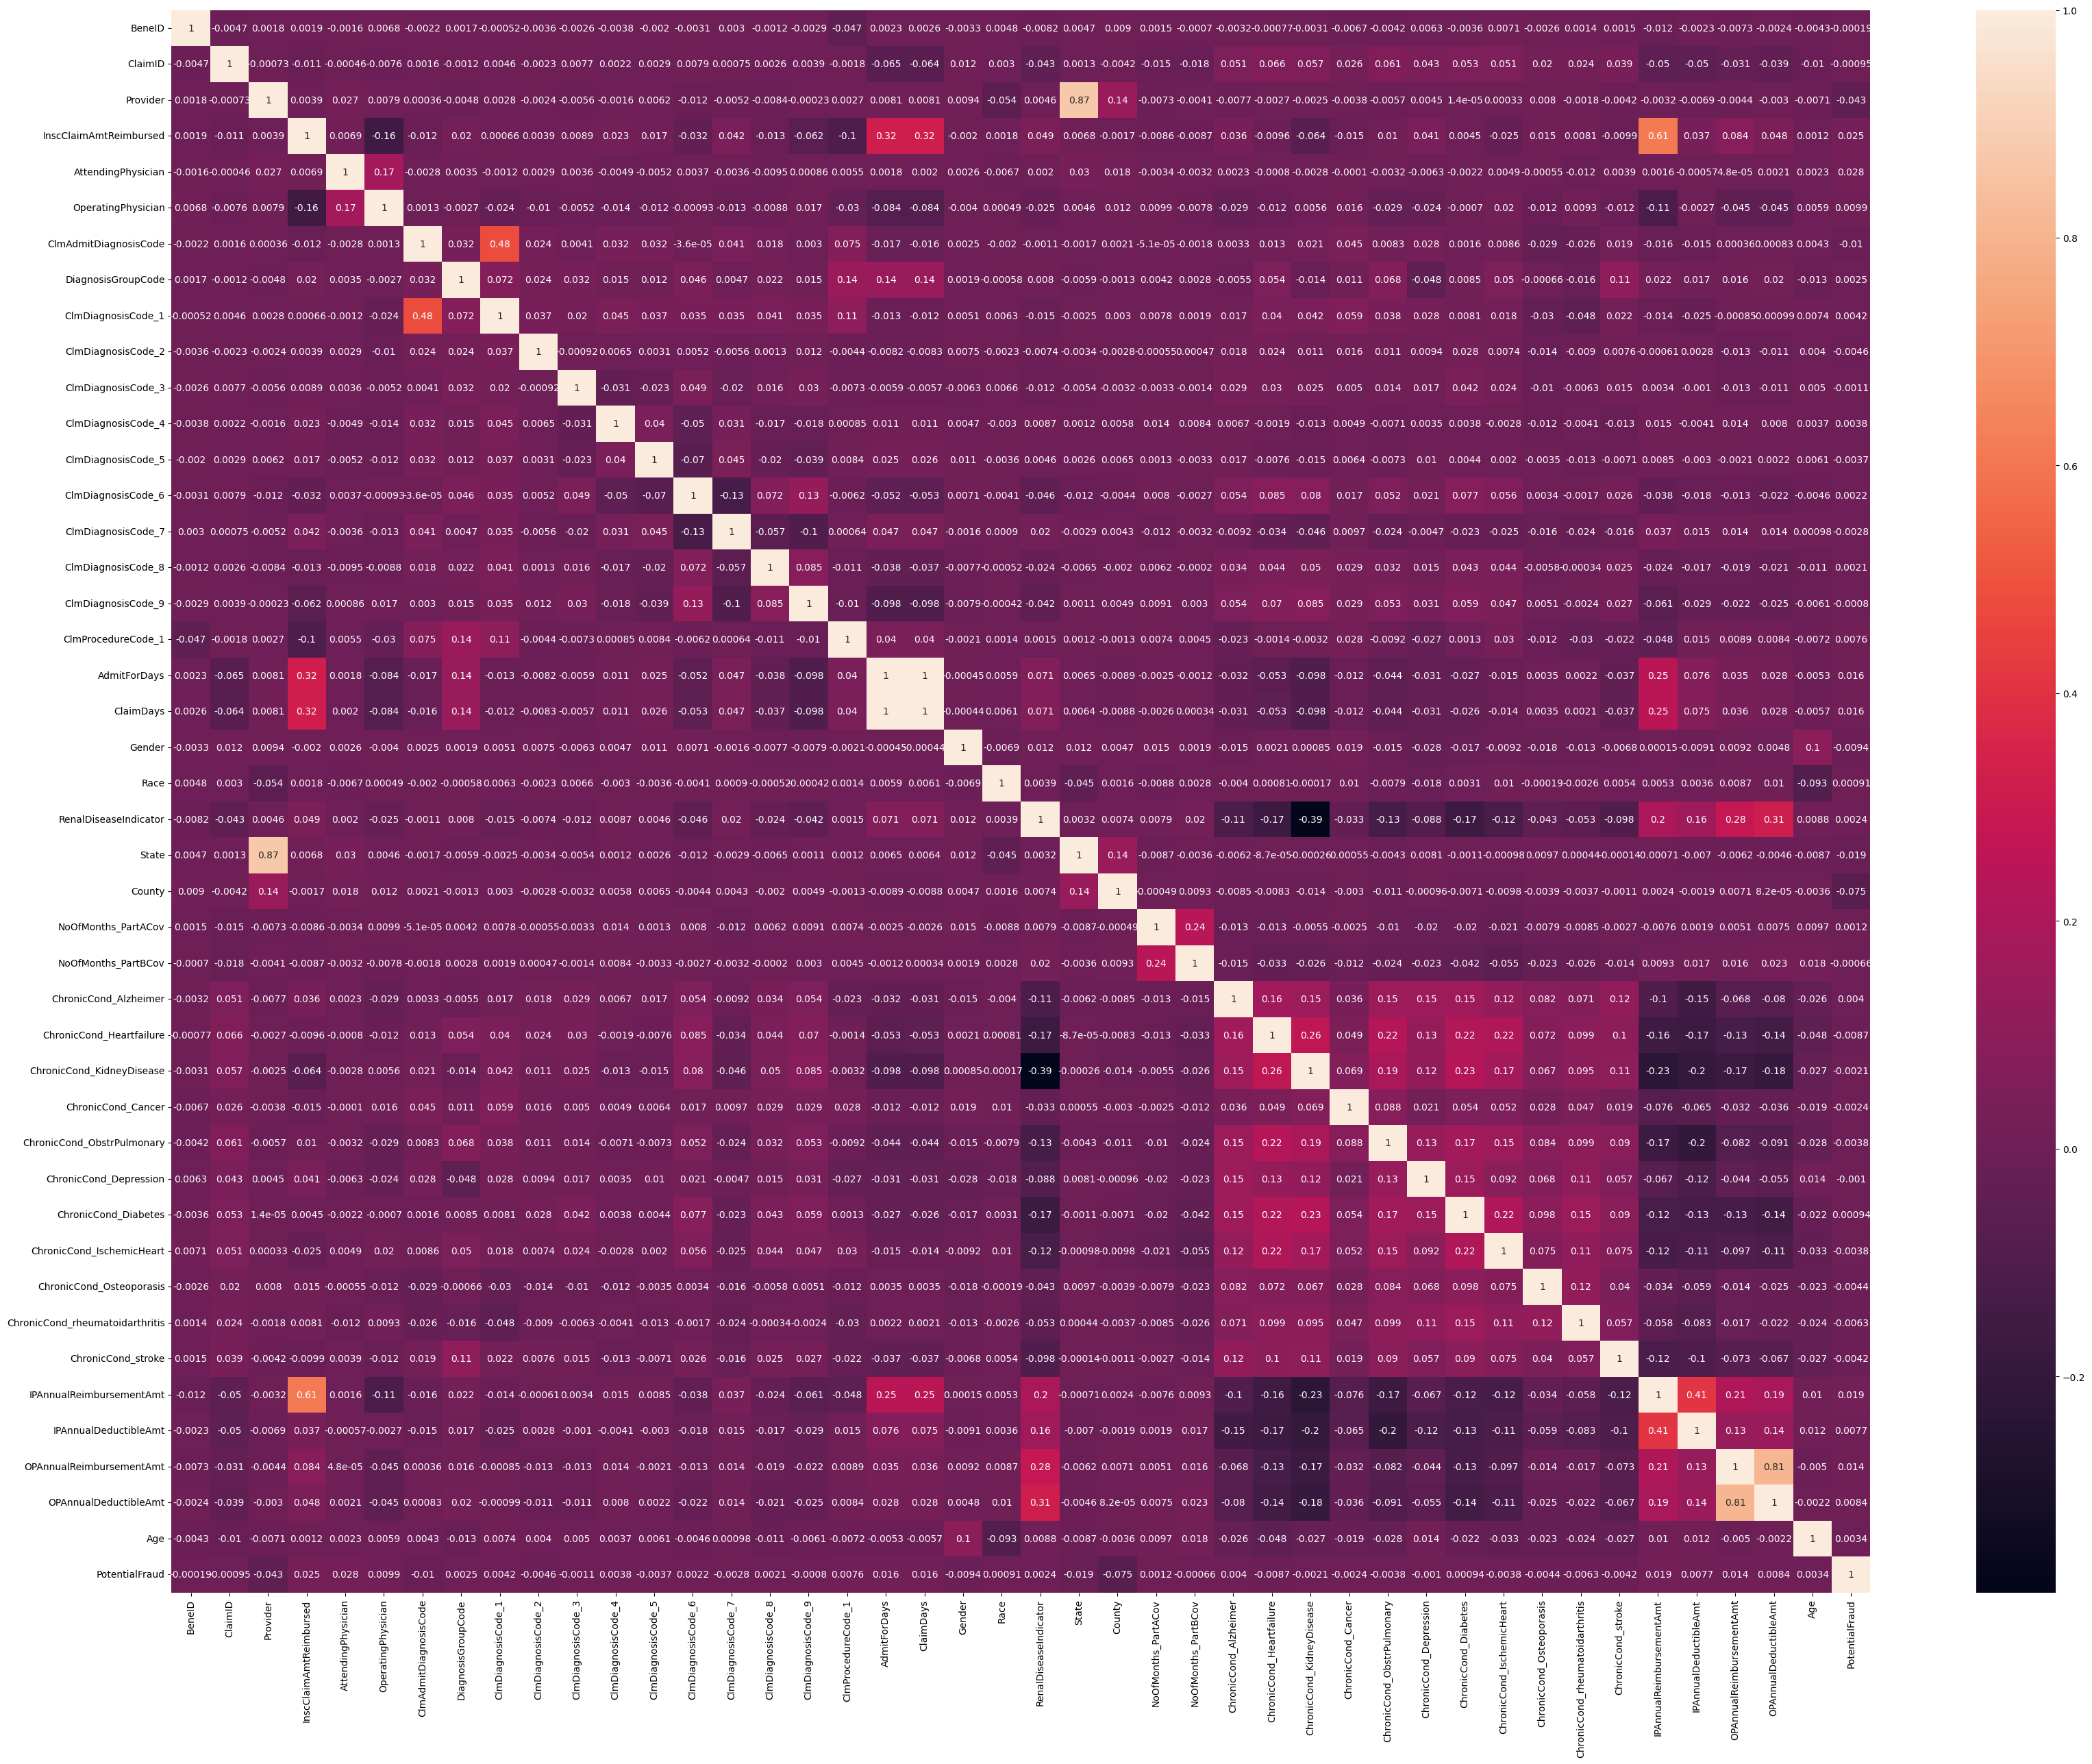

In [60]:
fdata1.drop('DeductibleAmtPaid',axis=1,inplace=True)
plt.figure(figsize=(40,30))
sns.heatmap(fdata1.corr(),annot=True)

<Axes: >

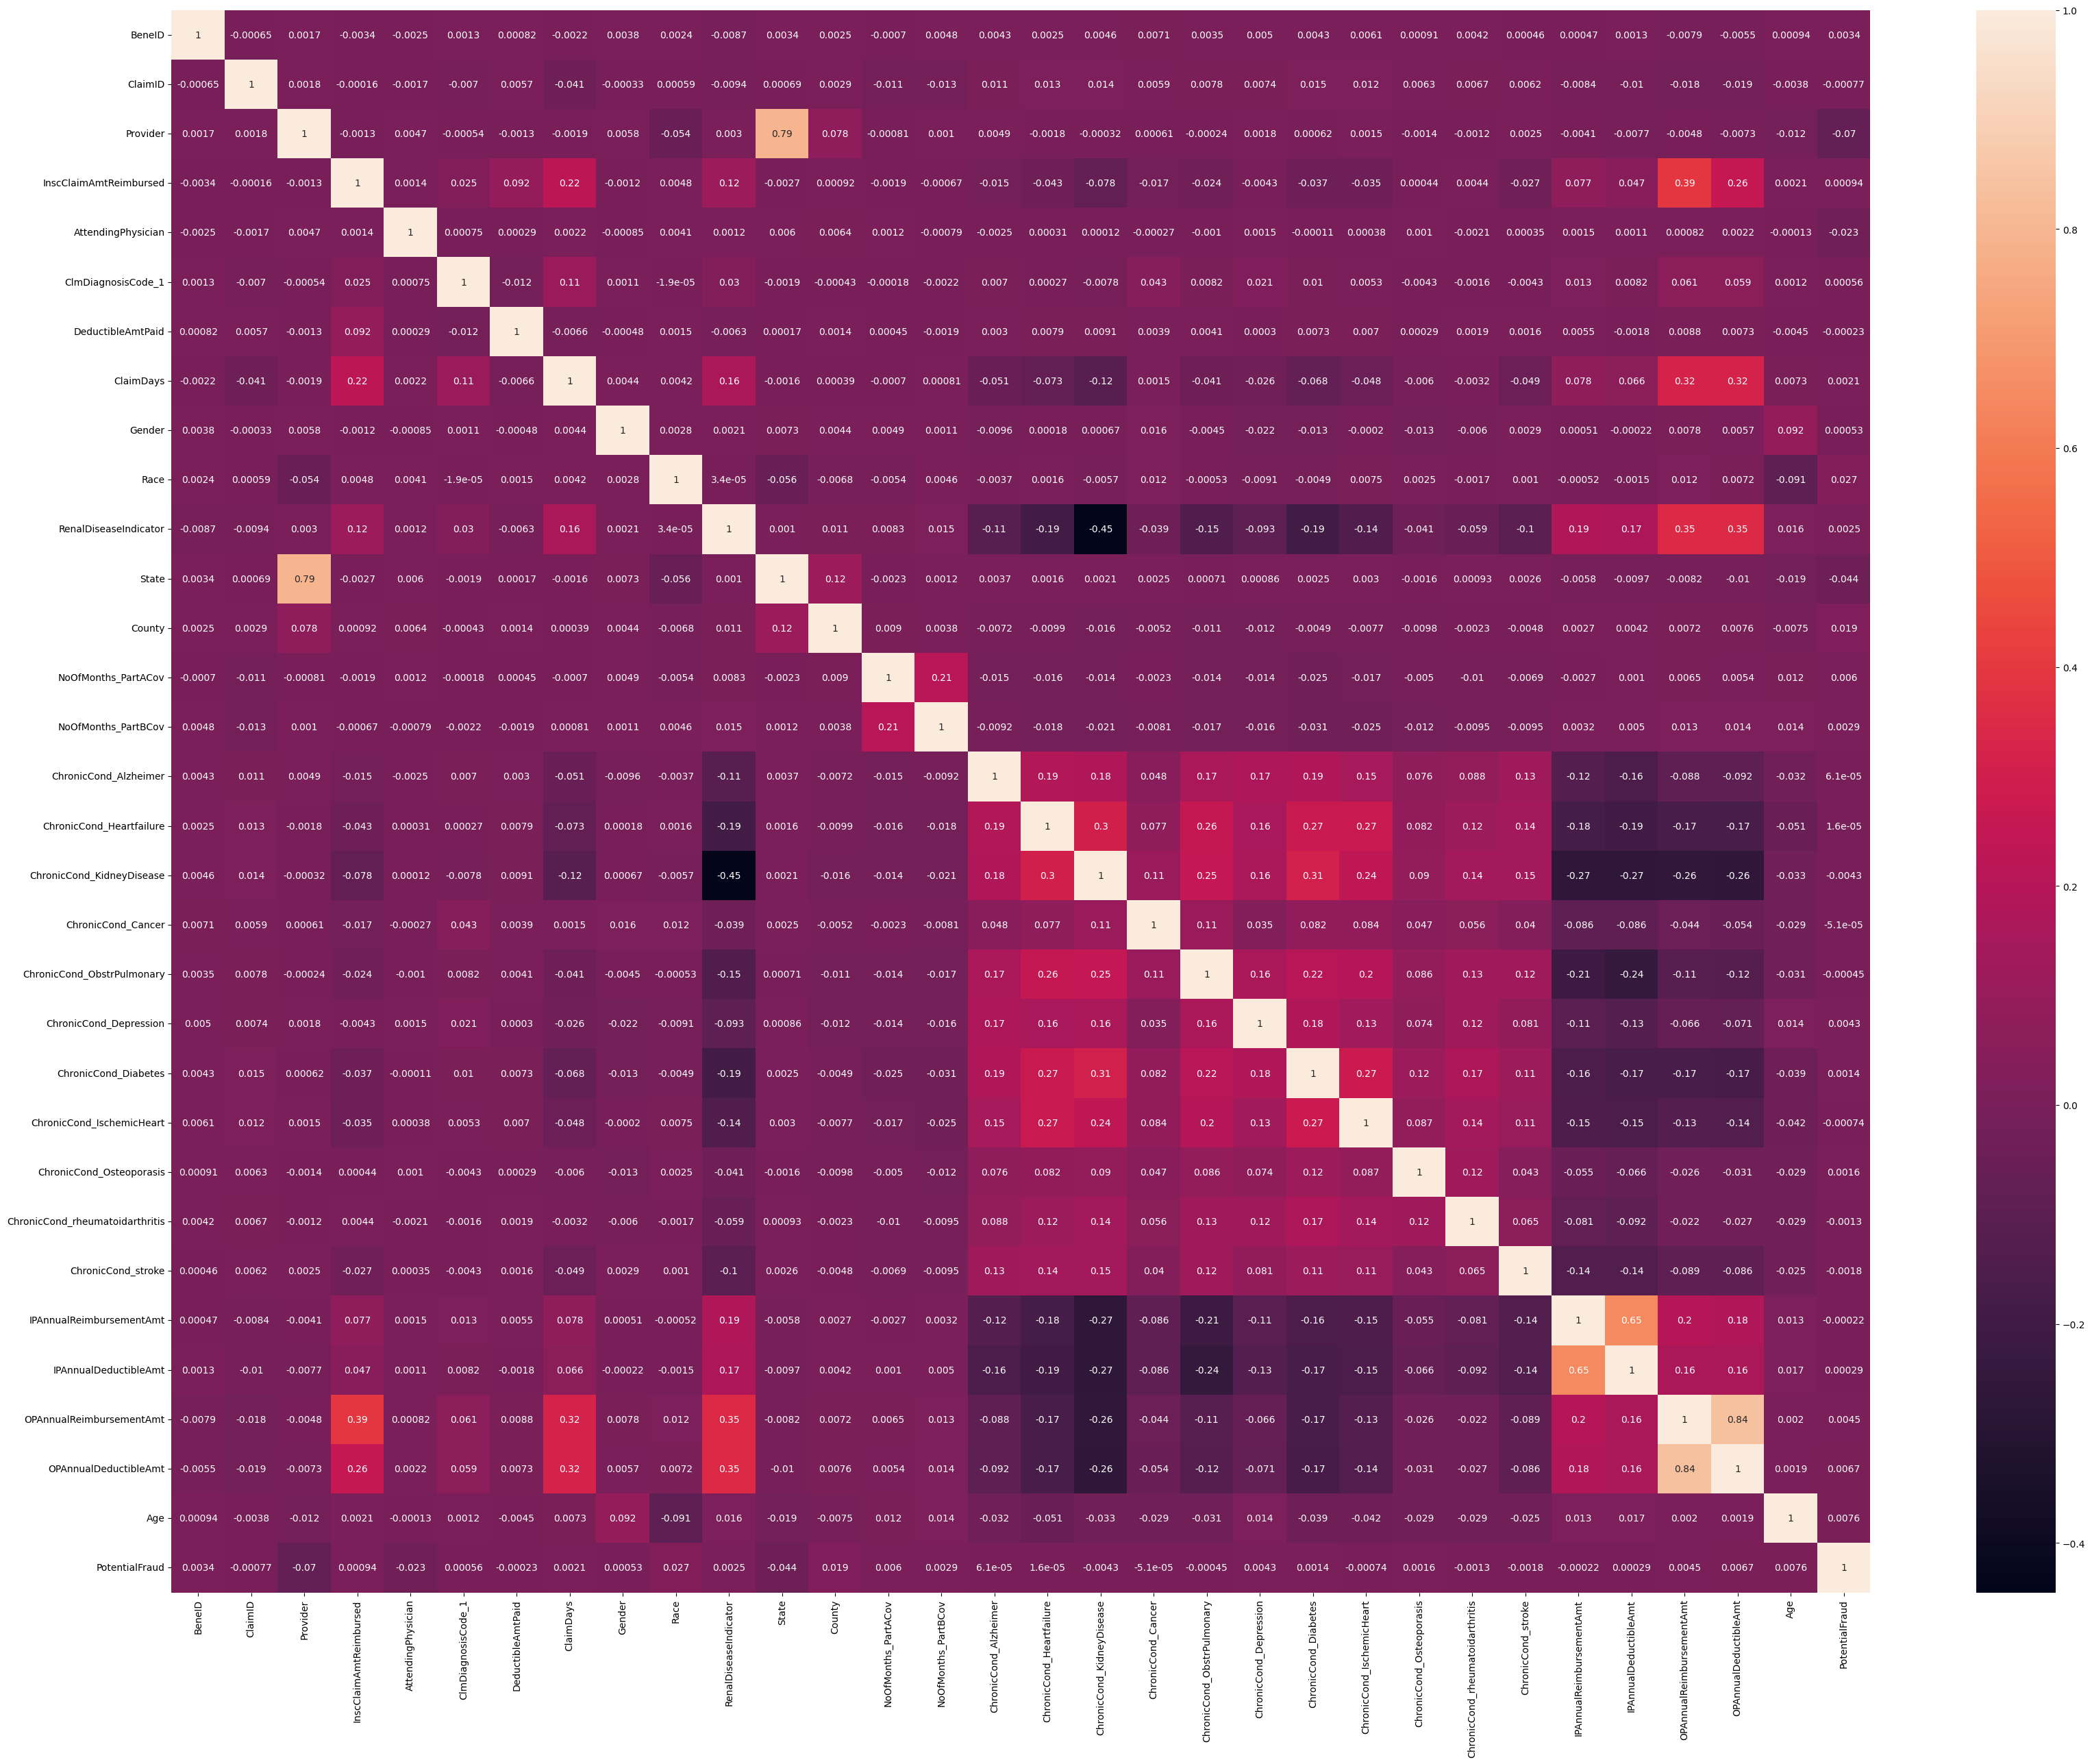

In [61]:
plt.figure(figsize=(40,30))
sns.heatmap(fdata2.corr(),annot=True)

In [62]:
#now we finally have a usable dataset fdata1 and fdata2
#where fdata1 captures inpatient scenario and fdata2 captures outpatient scenario

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [64]:
print("Inpatient: ",fdata1.shape)
print("Outpatient ",fdata2.shape)

Inpatient:  (40474, 44)
Outpatient  (517737, 32)


In [65]:
fdata1.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,ClmAdmitDiagnosisCode,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,2141,12665,1543,26000,7483,6821,1464,154,221,722,...,1,2,1,1,36000,3204,60,70,67.0,1
1,2141,28399,1540,5000,657,484,1127,580,1396,412,...,1,2,1,1,36000,3204,60,70,67.0,0
2,2141,30241,1585,5000,5789,6821,400,665,531,464,...,1,2,1,1,36000,3204,60,70,67.0,0
3,2163,6040,540,5000,5542,5530,679,52,886,307,...,2,2,1,1,5000,1068,250,320,96.0,0
4,2173,26500,1753,10000,6412,5896,1432,721,41,491,...,1,2,2,2,21260,2136,120,100,72.0,0


In [66]:
fdata2.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,ClmDiagnosisCode_1,DeductibleAmtPaid,ClaimDays,Gender,Race,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,9080,413702,3726,30,9159,7242,0,1,2,1,...,2,2,2,2,0,0,30,50,73.0,1
1,9090,64215,4894,80,31170,5309,0,1,1,1,...,1,2,2,2,0,0,90,40,73.0,0
2,9090,263736,4883,10,10806,1853,0,1,1,1,...,1,2,2,2,0,0,90,40,73.0,0
3,9099,9430,3726,40,14065,6350,0,1,1,1,...,1,1,1,2,0,0,1810,760,87.0,1
4,9099,32966,3726,200,55907,7912,0,1,1,1,...,1,1,1,2,0,0,1810,760,87.0,1


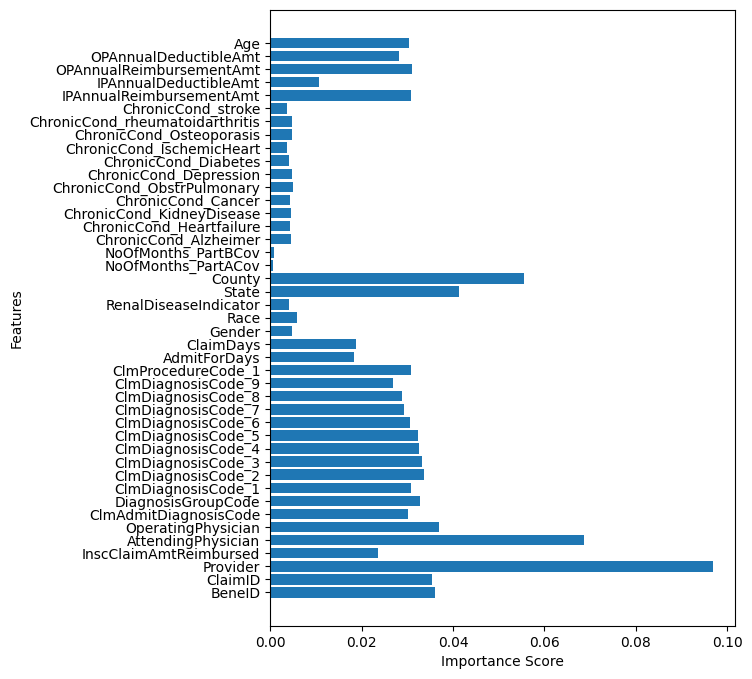

In [67]:
#manual feature selection
#inpatient dataset
X1=fdata1.iloc[:,:-1]
y1=fdata1.iloc[:,-1]
rf1 = RandomForestClassifier(n_estimators=60,random_state=42)
rf1.fit(X1,y1)
#ploting the importance scorces
arr=fdata1.columns.tolist()
arr.remove('PotentialFraud')
plt.figure(figsize=(6,8))
feature_names = list(arr)
plt.barh(feature_names, rf1.feature_importances_)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

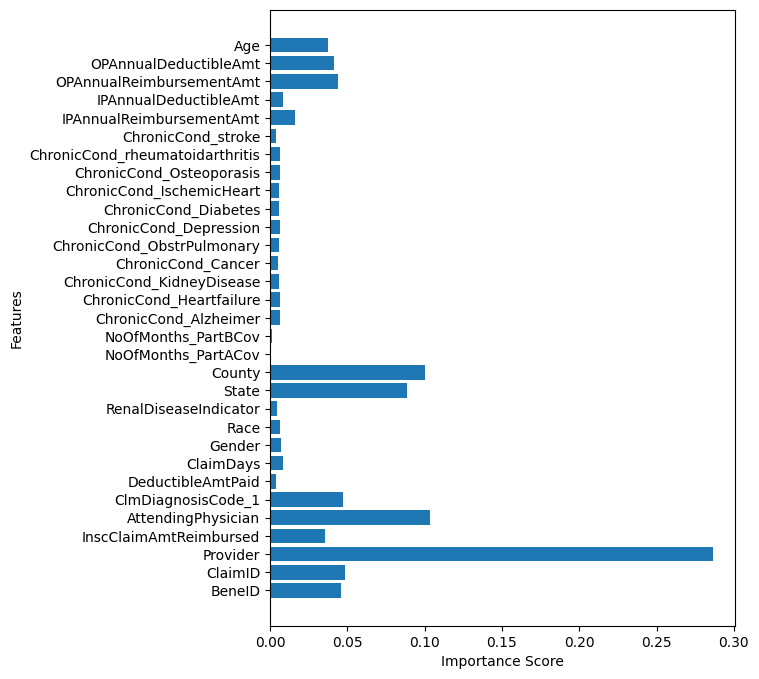

In [68]:
#outpatient dataset
X2=fdata2.iloc[:,:-1]
y2=fdata2.iloc[:,-1]
rf2 = RandomForestClassifier(n_estimators=60,random_state=42,)
rf2.fit(X2,y2)
#ploting the importance scores
arr=fdata2.columns.tolist()
arr.remove('PotentialFraud')
plt.figure(figsize=(6,8))
feature_names = list(arr)
plt.barh(feature_names, rf2.feature_importances_)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [69]:
print("for in patient:",rf1.feature_importances_)
print("for out patient:",rf2.feature_importances_)

for in patient: [0.03613575 0.0353325  0.09681949 0.02371188 0.06872594 0.0368609
 0.03008561 0.03275336 0.03090313 0.03363942 0.03313688 0.0326491
 0.03231582 0.0306941  0.02919843 0.02883176 0.02696935 0.03091027
 0.01842981 0.01883154 0.00477646 0.00582457 0.00418923 0.04132673
 0.05558572 0.00069121 0.00076625 0.00461035 0.00446977 0.00467787
 0.00430442 0.00496204 0.00481806 0.00418798 0.0036169  0.00484576
 0.00475102 0.00366598 0.03080418 0.01065665 0.03099283 0.02821561
 0.03032539]
for out patient: [0.04588734 0.04832328 0.28641567 0.03538591 0.10353603 0.04740413
 0.00392951 0.00812277 0.00705705 0.00648034 0.00481359 0.08861188
 0.10014532 0.00065824 0.00095491 0.00675524 0.00662075 0.00578488
 0.00490992 0.00608016 0.00639864 0.0059956  0.00593321 0.00636015
 0.00659363 0.00394153 0.01627097 0.00840039 0.04368839 0.04111689
 0.03742371]


In [70]:
threshold = 0.04 #select the threshold to select the most important features
selected_columns = np.where(rf1.feature_importances_ > threshold)[0]
selected_features_1 = fdata1.columns[selected_columns]
print("Selected features:",selected_features_1)

Selected features: Index(['Provider', 'AttendingPhysician', 'State', 'County'], dtype='object')


In [71]:
threshold = 0.02 #select the threshold to select the most important features
selected_columns = np.where(rf2.feature_importances_ > threshold)[0]
selected_features_2 = fdata2.columns[selected_columns]
print("Selected features:",selected_features_2)

Selected features: Index(['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'ClmDiagnosisCode_1', 'State', 'County',
       'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'Age'],
      dtype='object')


In [72]:
#creating a new dataFrame with the most important features
xf1=fdata1.loc[:,selected_features_1]
y1=pd.DataFrame(y1,columns=['PotentialFraud'])
fdata1_test=fdata1_test.loc[:,selected_features_1]
fdata1=pd.concat([xf1,y1],axis=1)

In [73]:
fdata1.shape

(40474, 5)

In [74]:
fdata1.head()

,Provider,AttendingPhysician,State,County,PotentialFraud
0,1543,7483,39,230,1
1,1540,657,39,230,0
2,1585,5789,39,230,0
3,540,5542,1,360,0
4,1753,6412,45,780,0


In [75]:
fdata1_test.head()

,Provider,AttendingPhysician,State,County
0,479,142,45,780
1,294,81,31,270
2,235,817,22,20
3,389,2544,38,200
4,130,1853,11,470


<Axes: >

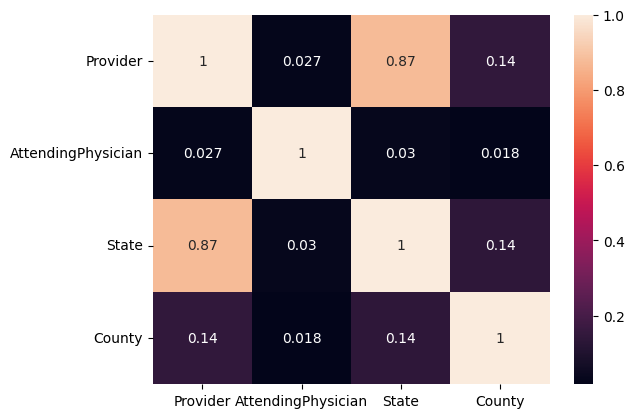

In [76]:
sns.heatmap(xf1.corr(),annot=True)

In [77]:
fdata1_test.shape

(9551, 4)

In [78]:
#creating new dataframe with the most important features
xf2=fdata2.loc[:,selected_features_2]
y2=pd.DataFrame(y2,columns=['PotentialFraud'])
fdata2_test=fdata2_test.loc[:,selected_features_2]
fdata2=pd.concat([xf2,y2],axis=1)

In [79]:
fdata2.shape

(517737, 12)

In [80]:
fdata2.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,ClmDiagnosisCode_1,State,County,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,9080,413702,3726,30,9159,7242,39,280,30,50,73.0,1
1,9090,64215,4894,80,31170,5309,52,590,90,40,73.0,0
2,9090,263736,4883,10,10806,1853,52,590,90,40,73.0,0
3,9099,9430,3726,40,14065,6350,39,270,1810,760,87.0,1
4,9099,32966,3726,200,55907,7912,39,270,1810,760,87.0,1


In [81]:
fdata2_test.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,ClmDiagnosisCode_1,State,County,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,4003,55276,919,30,5812,7937,39,230,60,70,67.0
1,4003,62812,953,30,11291,7093,39,230,60,70,67.0
2,4020,24118,1125,200,18233,5281,45,610,1490,160,69.0
3,4020,75697,1038,10,13108,4181,45,610,1490,160,69.0
4,4020,80644,1038,10,16992,8051,45,610,1490,160,69.0


In [82]:
fdata2_test.shape

(125841, 11)

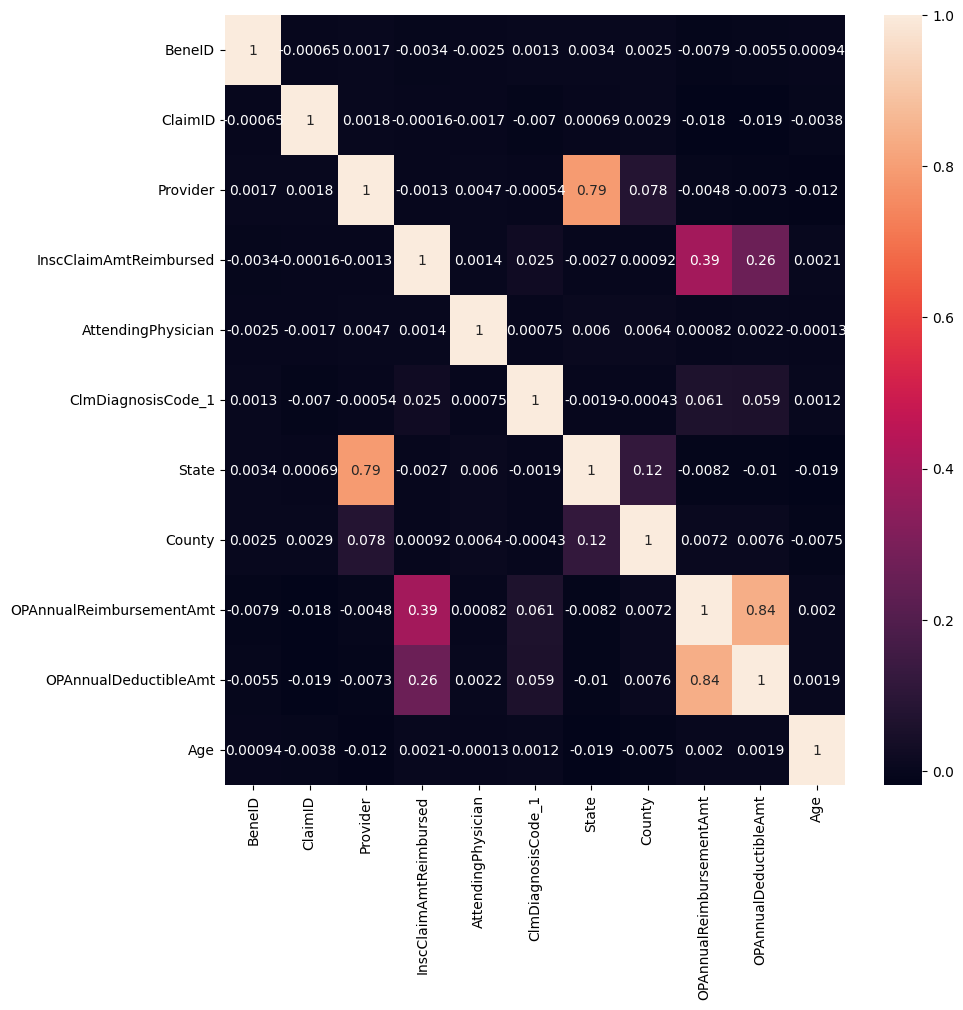

In [83]:
plt.figure(figsize=(10, 10))
sns.heatmap(xf2.corr(),annot=True)
plt.show()

In [84]:
#standardising inpatient inputs
inX=fdata1.iloc[:,:-1]
iny=fdata1.iloc[:,-1]
inx=StandardScaler().fit_transform(inX)

#standardising outpatient inputs
outX=fdata2.iloc[:,:-1]
outy=fdata2.iloc[:,-1]
outx=StandardScaler().fit_transform(outX)

In [85]:
#check the imbalance in datasets
print((fdata1['PotentialFraud'].value_counts()/len(fdata1))*100)
print((fdata2['PotentialFraud'].value_counts()/len(fdata2))*100)

PotentialFraud
1    57.819835
0    42.180165
Name: count, dtype: float64
PotentialFraud
0    63.418879
1    36.581121
Name: count, dtype: float64


dataset spliting


In [86]:
inX_train,inX_test,iny_train,iny_test=train_test_split(inX,iny,test_size=0.2,random_state=42)  #inpatient dataset
outX_train,outX_test,outy_train,outy_test=train_test_split(outX,outy,test_size=0.2,random_state=42)  #outopatient data set

addressing class imbalance by sampling techniques

In [87]:
inX_train,iny_train=SMOTE().fit_resample(inX_train,iny_train) #oversampling for inpatient data
outX_train,outy_train=RandomUnderSampler().fit_resample(outX_train,outy_train) #undersampling for outpatient data

In [88]:
#inpatient Random Forest
rf1 = RandomForestClassifier(n_estimators=60,random_state=42)
scores = cross_val_score(rf1, inX_train, iny_train, cv=5, scoring='accuracy')
# Printing the scores
print("Accuracy scores:", scores)
print("the Training accuracy:", scores.mean()*100)
rf1.fit(inX_train,iny_train)
predict1=rf1.predict(inX_test)
print("the Testing accuracy:", accuracy_score(iny_test, predict1)*100)
print("the f1 score is : ",f1_score(iny_test, predict1)*100)
print("classification report:\n ",classification_report(iny_test,predict1))

Accuracy scores: [0.93622995 0.94384276 0.94116861 0.94651691 0.94531354]
the Training accuracy: 94.26143540594592
the Testing accuracy: 94.6757257566399
the f1 score is :  95.37206056050682
classification report:
                precision    recall  f1-score   support

           0       0.92      0.95      0.94      3391
           1       0.96      0.94      0.95      4704

    accuracy                           0.95      8095
   macro avg       0.94      0.95      0.95      8095
weighted avg       0.95      0.95      0.95      8095



In [89]:
#outpatient Random Forest
rf2 = RandomForestClassifier(n_estimators=60,random_state=42)
scores = cross_val_score(rf2, outX_train, outy_train, cv=5, scoring='accuracy')
#printing the scores
print("Accuracy scores:", scores)
print("The Training accuracy:", scores.mean()*100)
rf2.fit(outX_train,outy_train)
predict2=rf2.predict(outX_test)
print("the Testing accuracy:", accuracy_score(outy_test, predict2)*100)
print("the f1 score is : ",f1_score(outy_test, predict2)*100)
print("classification report:\n ",classification_report(outy_test,predict2))

Accuracy scores: [0.93463643 0.93569121 0.93844354 0.938904   0.93616811]
The Training accuracy: 93.6768656708107
the Testing accuracy: 95.1037200139066
the f1 score is :  93.22952833716147
classification report:
                precision    recall  f1-score   support

           0       0.96      0.97      0.96     65843
           1       0.94      0.93      0.93     37705

    accuracy                           0.95    103548
   macro avg       0.95      0.95      0.95    103548
weighted avg       0.95      0.95      0.95    103548



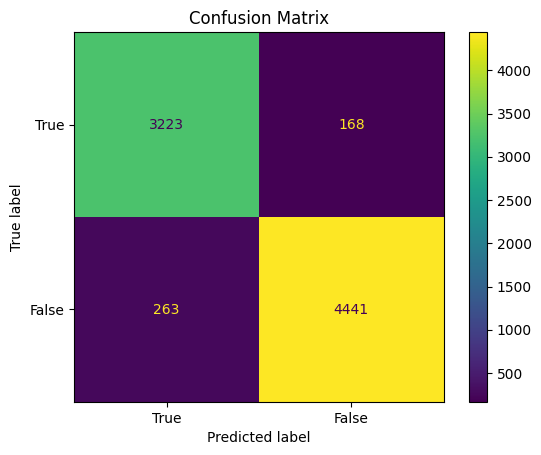

In [90]:
cnf_matrix = confusion_matrix(iny_test,predict1)
ConfusionMatrixDisplay(confusion_matrix  = cnf_matrix,display_labels = [True, False]).plot()
plt.title('Confusion Matrix')
plt.show()

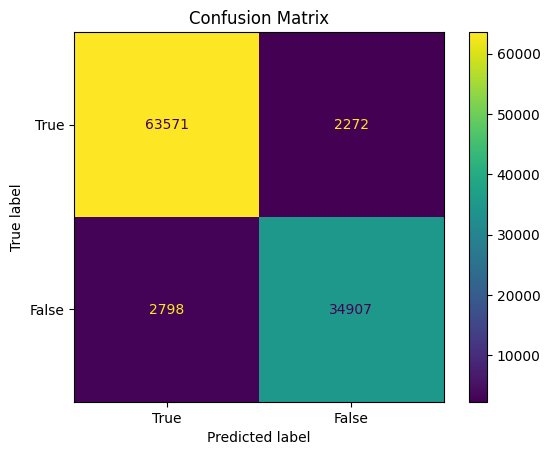

In [91]:
cnf_matrix = confusion_matrix(outy_test,predict2)
ConfusionMatrixDisplay(confusion_matrix  = cnf_matrix,display_labels = [True, False]).plot()
plt.title('Confusion Matrix')
plt.show()

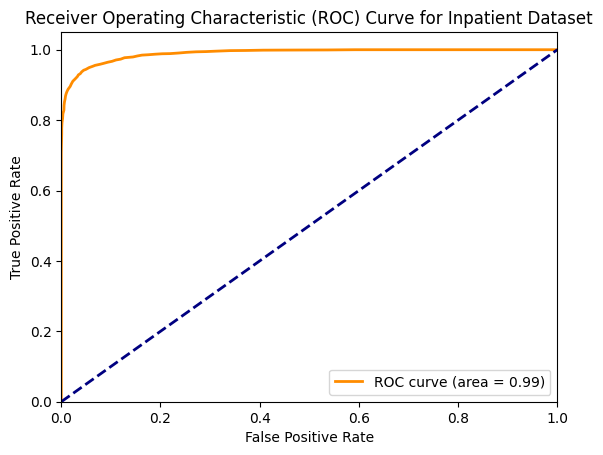

In [92]:
iny_pred_proba = rf1.predict_proba(inX_test)[:, 1]
fpr, tpr, _ = roc_curve(iny_test, iny_pred_proba)
roc_auc = auc(fpr, tpr)
# Plotting ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Inpatient Dataset')
plt.legend(loc="lower right")
plt.show()

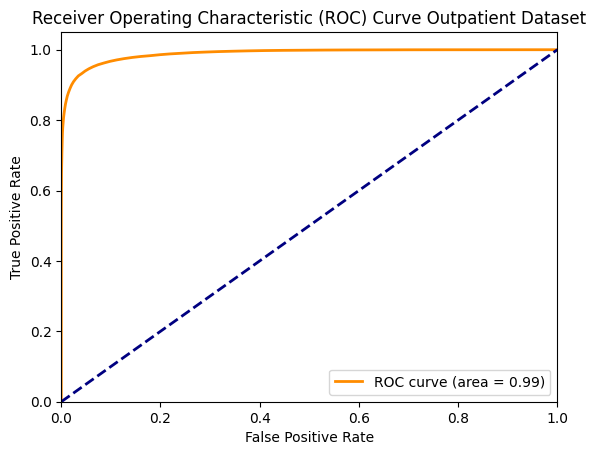

In [93]:
outy_pred_proba = rf2.predict_proba(outX_test)[:, 1]
fpr, tpr, _ = roc_curve(outy_test, outy_pred_proba)
roc_auc = auc(fpr, tpr)
# Plotting ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Outpatient Dataset')
plt.legend(loc="lower right")
plt.show()

In [94]:
clf1 = DecisionTreeClassifier()
cores = cross_val_score(clf1, inX_train, iny_train, cv=5, scoring='accuracy')
# Print the scores
print("Accuracy scores:", scores)
print(" the Training accuracy:", scores.mean()*100)
clf1.fit(inX_train, iny_train)
predict3 = clf1.predict(inX_test)
print("the Testing accuracy:", accuracy_score(iny_test, predict3)*100)
print("the f1 score is : ",f1_score(iny_test, predict3)*100)
print("classification report:\n ",classification_report(iny_test, predict3))

Accuracy scores: [0.93463643 0.93569121 0.93844354 0.938904   0.93616811]
 the Training accuracy: 93.6768656708107
the Testing accuracy: 94.30512662137122
the f1 score is :  95.10771516502176
classification report:
                precision    recall  f1-score   support

           0       0.93      0.93      0.93      3391
           1       0.95      0.95      0.95      4704

    accuracy                           0.94      8095
   macro avg       0.94      0.94      0.94      8095
weighted avg       0.94      0.94      0.94      8095



In [95]:
clf2 = DecisionTreeClassifier()
scores = cross_val_score(clf2, outX_train, outy_train, cv=5, scoring='accuracy')
# Print the scores
print("Accuracy scores:", scores)
print("the Training accuracy:", scores.mean()*100)
clf2.fit(outX_train, outy_train)
predict4 = clf2.predict(outX_test)
print("the Testing accuracy:", accuracy_score(outy_test, predict4)*100)
print("the f1 score is : ",f1_score(outy_test, predict4)*100)
print("classification report:\n ",classification_report(outy_test, predict4))

Accuracy scores: [0.99126508 0.99088602 0.99045751 0.99146271 0.99047384]
the Training accuracy: 99.09090313684065
the Testing accuracy: 99.14918685054275
the f1 score is :  98.83642607145215
classification report:
                precision    recall  f1-score   support

           0       1.00      0.99      0.99     65843
           1       0.98      0.99      0.99     37705

    accuracy                           0.99    103548
   macro avg       0.99      0.99      0.99    103548
weighted avg       0.99      0.99      0.99    103548



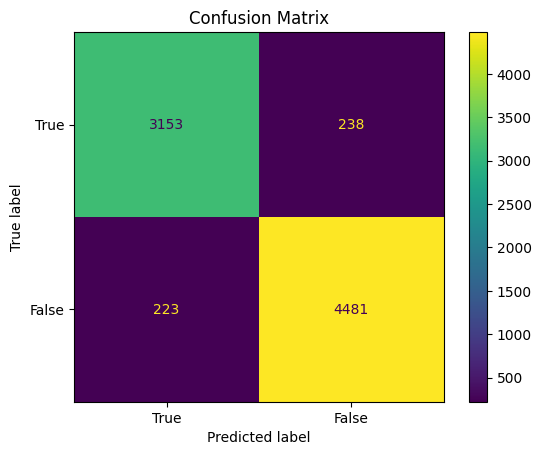

In [96]:
cnf_matrix = confusion_matrix(iny_test,predict3)
ConfusionMatrixDisplay(confusion_matrix  = cnf_matrix,display_labels = [True, False]).plot()
plt.title('Confusion Matrix')
plt.show()

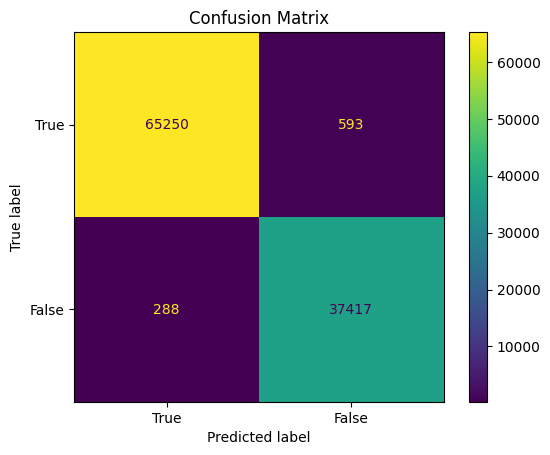

In [97]:
cnf_matrix = confusion_matrix(outy_test,predict4)
ConfusionMatrixDisplay(confusion_matrix  = cnf_matrix,display_labels = [True, False]).plot()
plt.title('Confusion Matrix')
plt.show()

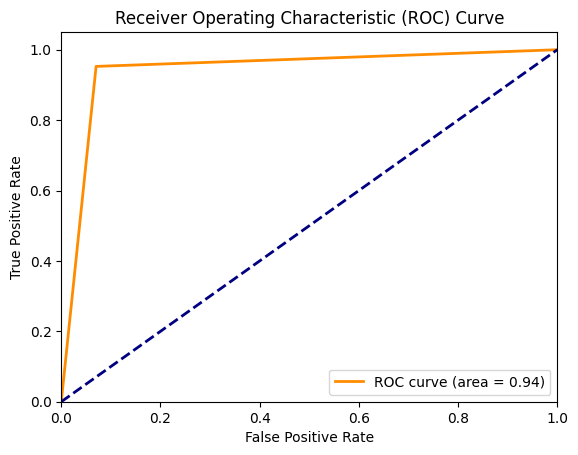

In [98]:
iny_pred_proba = clf1.predict_proba(inX_test)[:, 1]
fpr, tpr, _ = roc_curve(iny_test, iny_pred_proba)
roc_auc = auc(fpr, tpr)
# Plot ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

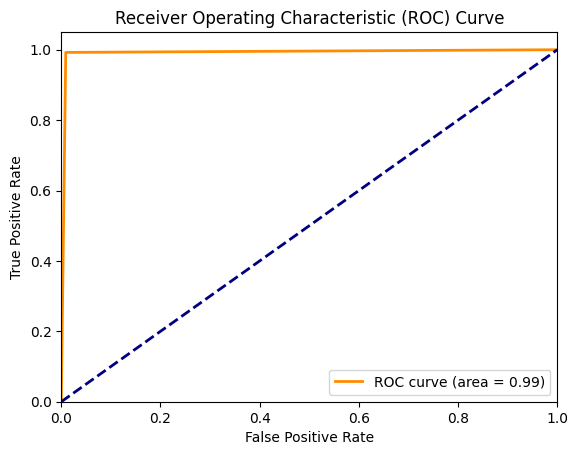

In [99]:
outy_pred_proba = clf2.predict_proba(outX_test)[:, 1]
fpr, tpr, _ = roc_curve(outy_test, outy_pred_proba)
roc_auc = auc(fpr, tpr)
# Plot ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [100]:


print("Random Forest")
c=0
pred=rf1.predict(fdata1_test)
for i in pred:
    if (i==1):
        c+=1
print("No of Potential Fraud: ",c)
print("No of genuiene: ",len(pred)-c)
print('\n\n')

print("Decision tree")
c=0
pred1=clf1.predict(fdata1_test)
for i in pred1:
    if (i==1):
        c+=1
print("No of Potential Fraud: ",c)
print("No of genuiene: ",len(pred1)-c)
print('\n\n')

Random Forest
No of Potential Fraud:  2365
No of genuiene:  7186



Decision tree
No of Potential Fraud:  2594
No of genuiene:  6957





In [101]:

print("Random Forest")
c=0
pred=rf2.predict(fdata2_test)
for i in pred:
    if (i==1):
        c+=1
print("No of Potential Fraud: ",c)
print("No of genuiene: ",len(pred)-c)
print('\n\n')

print("Decision tree")
c=0
pred1=clf2.predict(fdata2_test)
for i in pred1:
    if (i==1):
        c+=1
print("No of Potential Fraud: ",c)
print("No of genuiene: ",len(pred1)-c)
print('\n\n')

Random Forest
No of Potential Fraud:  28988
No of genuiene:  96853



Decision tree
No of Potential Fraud:  21859
No of genuiene:  103982



